<a href="https://colab.research.google.com/github/RojasG4mer/Fundamentos-de-Procesamiento-Digital-de-Imagenes/blob/main/Filtros_en_el_dominio_del_espacio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


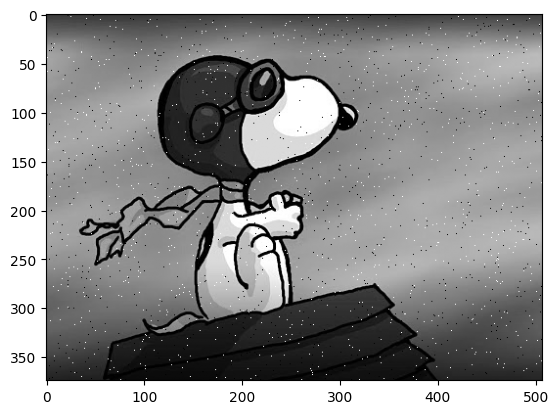

374 507


In [6]:

ruta = '/content/drive/MyDrive/Procesamiento Digital del Imágenes/Imagenes/salt-snoopy.png' # snoopy salt
# '/content/drive/MyDrive/Procesamiento Digital del Imágenes/Imagenes/salt-perry2.png' # Perry salt&peper]
# '/content/drive/MyDrive/Procesamiento Digital del Imágenes/Imagenes/gato_nojao.jpg' # gato nojao
# '/content/drive/MyDrive/Procesamiento Digital del Imágenes/Imagenes/bebida.jpg' # Bebida
ima_rgb = cv2.imread(ruta)
ima_grises = cv2.cvtColor(ima_rgb, cv2.COLOR_BGR2GRAY)
plt.imshow(ima_grises, cmap = 'gray')
plt.show()
y, x = ima_grises.shape
print(y, x)

# Operaciones espaciales

Se efectúan teniendo en cuenta a los puntos vecinos.

Ejemplos:
1.  Promediado espacial: Cada píxel se sustituye por un promedio de sus píxeles vecinos.
2.  Suavizado direccional: para proteger a los bordes de la difuminación.
3.

## Promediado espacial

Relación entre píxeles y máscara de convolución.

La matrices son ventanas de tamaño None (impar), ya que así tenemos un centro bien definido.

### Kernel
Matriz de pesos que se aplica a cada región de la imagen, donde el resultado de la operación debe quedar en el pixel central (en una imagen nueva).

## Filtros en el dominio del espacio: filtros lineales

### Tratamiento de límites de la imagen

Puede aplicarse la máscara extendiendo la imagen con un marco de ceros de la anchura adecuada.

Esto puede tener efectos no deseados (ejemplo difuminación de los límites de la imagen) pero, en general, poco significativos si la máscara es pequeña en relación con el tamaño de la imagen.


In [7]:
def padding(imagen, dx):
  y, x = imagen.shape
  paddineada = np.zeros((int(y + dx/2 + 1), int(x + dx/2 + 1)))
  for j in range(y):
    for i in range(x):
      paddineada[int(j + dx/2)][int(i + dx/2)] = imagen[j][i]
  return np.array(paddineada)

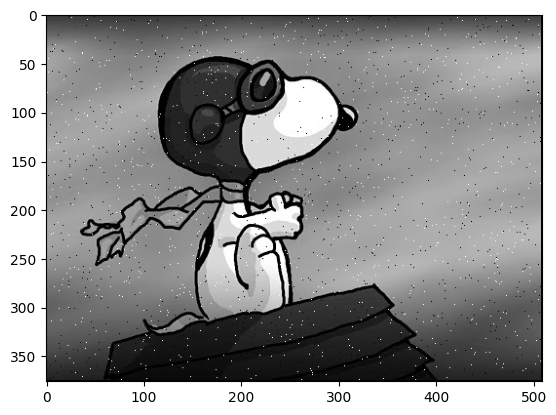

376 509


In [8]:
padeada = padding(ima_grises, 3)
plt.imshow(padeada, cmap = 'gray')
plt.show()
y, x = padeada.shape
print(y, x)

### Filtro de la media

El filtro de la media es el más simple, intuitivo y fácil de implementar para suavizar imágenes que el de la mediana, es decir, reducir la cantidad de variaciones de intensidad entre píxeles vecinos.

Se visita cada píxel de la imagen,


Desventajas:
1.  Es mśa sensible a cambios locales.
2.  Puede crear nuevas intesidades de grises que no aparecían en la imagen.

In [9]:
def media_matrix(matrix):
  y, x = matrix.shape
  N = y * x
  media = 0
  for j in range(y):
    for i in range(x):
      media += matrix[j][i]
  media = media / N
  return media

In [10]:
def media_matrix_metodo2(matrix):
  N = 0
  media = 0
  for j in matrix:
    for i in j:
      media += i
      N += 1
  media = media / N
  return media

In [11]:
def aplica_filtro_media(image, filtro_ap, lado_cuadrado):
  # Ciclo para aplicar el filtro sobre la imagen:
  y, x = ima_grises.shape
  ima_padding = padding(ima_grises, lado_cuadrado)
  yp, xp = ima_padding.shape
  print('Long x: ', xp, 'Long y: ', yp)
  ima_filtrada = np.zeros((y, x))
  cuadrado_temp_delaimag = np.zeros((lado_cuadrado, lado_cuadrado))
  for j in range(y-lado_cuadrado+1): # Fila
    for i in range(x-lado_cuadrado+1): # Columna
      #Entramos a la sección específica de la imagen (rectángulo)
      for k in range(lado_cuadrado):
        for l in range(lado_cuadrado):
          cuadrado_temp_delaimag[k][l] = ima_padding[j + k][i + l]
      filtro = filtro_ap(cuadrado_temp_delaimag)
      ima_filtrada[j][i] = filtro
  return ima_filtrada

Long x:  509 Long y:  376


Text(0.5, 1.0, 'Imagen con filtro media')

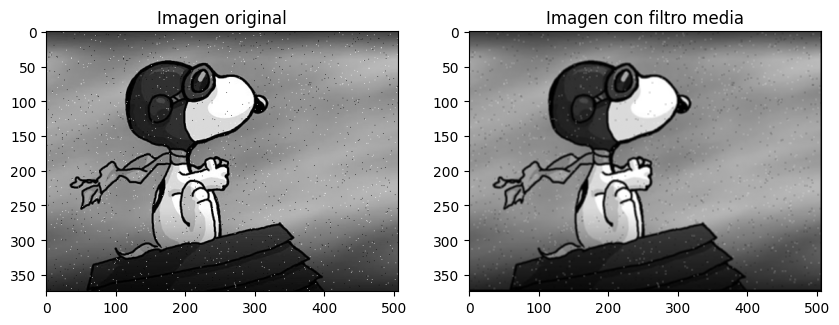

In [12]:
ima_filtrada = aplica_filtro_media(ima_grises, media_matrix, 3)
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
axs[0].imshow(ima_grises, cmap = 'gray')
axs[0].set_title('Imagen original')
axs[1].imshow(ima_filtrada, cmap = 'gray')
axs[1].set_title('Imagen con filtro media')

### Filtro Gaussiano

SE usa para emborronar imágenes y eliminar ruido. Es similar al filtro de media pero se usa una máscara diferente, modelizando la función gaussiana:
$$ G(x, y) = \frac{1}{2\pi\sigma^2} exp[-(x^2 + y^2)/2\sigma^2] $$
Este kernel le da menos peso a los píxeles más alejados del centro y uno mayor a los más cercanos a este.

Caracteristicas:
1.  Disminución de nitidez.
2.  Aumento de borrosidad.
3.  

Ventajas:
1.  Es separable: en lugar de realizar una convolución bidimensional, podemos realizar dos convoluciones unidimensionales. UNa en sentido horizonal y otra en sentido vertical.
2.  El filtro gaussiano produce un suavizado más uniforme que el filtro de media.


### Filtro Gaussiano

El filtro Gaussiano se utiliza para emborronar imágenes y eliminar ruido. Es similar al filtro de la media pero utiliza una máscara diferente, modelando la función Gaussiana bidimensional:

$$ G(x, y) = \frac{1}{2\pi\sigma^2} e^{-(x^2 + y^2)/(2\sigma^2)} $$

Donde:
*   `(x, y)` son las coordenadas de un punto en el kernel, con el centro en (0,0).
*   `$\sigma$` (sigma) es la desviación estándar, que controla el grado de suavizado. Un valor de `$\sigma$` más grande resultará en un desenfoque más significativo.

Este kernel le da menos peso a los píxeles más alejados del centro y uno mayor a los más cercanos a este. El peso de cada píxel en el kernel se determina por su distancia al centro y el valor de `$\sigma$`.

**Características:**
1.  Disminución de nitidez.
2.  Aumento de borrosidad.
3.  Efectivo en la reducción de ruido Gaussiano.

**Ventajas:**
1.  **Es separable:** En lugar de realizar una convolución bidimensional, podemos realizar dos convoluciones unidimensionales (una en sentido horizontal y otra en sentido vertical). Esto mejora la eficiencia computacional.
2.  El filtro Gaussiano produce un suavizado más uniforme y natural que el filtro de la media, ya que considera la distancia de los píxeles al centro.

Para aplicar el filtro, necesitamos crear una matriz (kernel) cuyos valores se basan en esta función Gaussiana. Luego, esta matriz se desliza sobre la imagen, y para cada posición, se realiza una suma ponderada de los píxeles de la imagen, donde los pesos son los valores del kernel.

In [13]:
def gaussian_kernel(size, sigma):
    # El tamaño del kernel debe ser impar para tener un centro
    if size % 2 == 0:
        raise ValueError("El tamaño del kernel debe ser un número impar")

    kernel = np.zeros((size, size))
    center = size // 2

    for y in range(size):
        for x in range(size):
            # Coordenadas relativas al centro del kernel
            rel_x = x - center
            rel_y = y - center

            # Fórmula Gaussiana 2D
            kernel[y][x] = (1 / (2 * np.pi * sigma**2)) * np.exp(-(rel_x**2 + rel_y**2) / (2 * sigma**2))

    # Normalizar el kernel para que la suma de sus elementos sea 1
    # Esto asegura que la intensidad general de la imagen no cambie
    return kernel / np.sum(kernel)

# Ejemplo de uso:
kernel_3x3 = gaussian_kernel(size=3, sigma=1.0)
print("Kernel Gaussiano 3x3 (sigma=1.0):\n", kernel_3x3)

kernel_5x5 = gaussian_kernel(size=5, sigma=1.5)
print("\nKernel Gaussiano 5x5 (sigma=1.5):\n", kernel_5x5)

Kernel Gaussiano 3x3 (sigma=1.0):
 [[0.07511361 0.1238414  0.07511361]
 [0.1238414  0.20417996 0.1238414 ]
 [0.07511361 0.1238414  0.07511361]]

Kernel Gaussiano 5x5 (sigma=1.5):
 [[0.01441882 0.02808402 0.0350727  0.02808402 0.01441882]
 [0.02808402 0.05470021 0.06831229 0.05470021 0.02808402]
 [0.0350727  0.06831229 0.08531173 0.06831229 0.0350727 ]
 [0.02808402 0.05470021 0.06831229 0.05470021 0.02808402]
 [0.01441882 0.02808402 0.0350727  0.02808402 0.01441882]]


In [14]:
def applica_gaussian_filter(image, kernel_size, sigma):
    # Generar el kernel Gaussiano
    kernel = gaussian_kernel(kernel_size, sigma)

    # Obtener dimensiones de la imagen y del kernel
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Calcular el padding necesario
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2

    # Crear una imagen con padding de ceros
    padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant', constant_values=0)

    # Crear una imagen para almacenar el resultado filtrado
    filtered_image = np.zeros_like(image, dtype=float)

    # Aplicar la convolución
    for y in range(img_height):
        for x in range(img_width):
            # Extraer la región de la imagen que coincide con el kernel
            region = padded_image[y:y + kernel_height, x:x + kernel_width]

            # Multiplicar la región por el kernel y sumar los resultados (convolución)
            filtered_image[y, x] = np.sum(region * kernel)

    return filtered_image.astype(np.uint8)

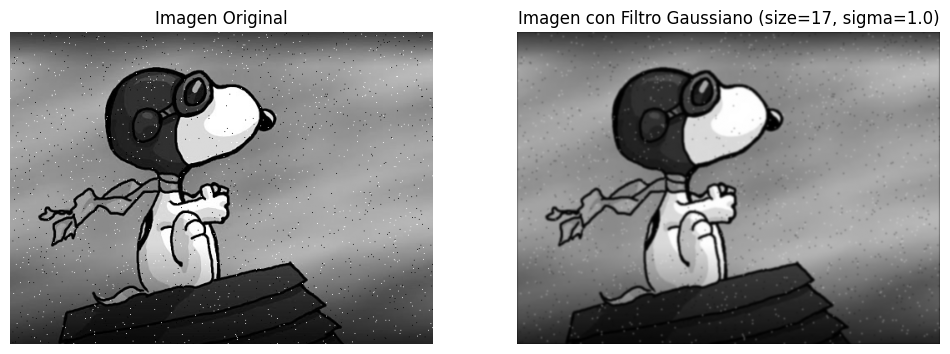

In [15]:
# Parámetros del filtro Gaussiano
kernel_size = 17  # Debe ser impar, por ejemplo 3, 5, 7...
sigma = 1.0     # Desviación estándar

# Aplicar el filtro Gaussiano a la imagen en escala de grises
ima_gaussiana = applica_gaussian_filter(ima_grises, kernel_size, sigma)

# Visualizar la imagen original y la imagen filtrada
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(ima_grises, cmap='gray')
axs[0].set_title('Imagen Original')
axs[0].axis('off')

axs[1].imshow(ima_gaussiana, cmap='gray')
axs[1].set_title(f'Imagen con Filtro Gaussiano (size={kernel_size}, sigma={sigma})')
axs[1].axis('off')

plt.show()

### Filtro de la mediana

Opera sobre una ventana seleccionando la intensidad mediana en la ventana.
**METODOS DE SORTING HACER UNA INVESTIGACIÓN**

Desventajas:
1. Depende del método para organizar los datos


## Sorting methods

They could be classificated by their efficiency. It can be obtained by counting the number of comparissons (C) of a key and the movements (M). The easiest ones to understand are *straight methods* which have $C = n^2$, another classification is according to their underlying method:
1. Sorting by insertion
2. Sorting by selection
3. Sorting by exchange



### Insertion sort

In [45]:
def insertion_sort(arr):
    key = 1
    lon_arr = len(arr)
    key = 1
    # arr_tem = [0]*lon_arr
    for i in range(lon_arr):
      for j in range(key):
        # print(j)
        if arr[j] < arr[i]:
          temp = arr[i]
          arr[i] = arr[j]
          arr[j] = temp
      # print(arr)
      key += 1
    return arr

In [47]:
def aplanado_arreglo(matrix):
  # Aplanamos la matriz de valores
  y, x = matrix.shape
  arr = [0]*(y*x)
  for j in range(y):
    for i in range(x):
      arr[j * x + i] = matrix[j][i]
  return np.array(arr)

In [52]:
def mediana_artesanal(matrix):
  # Aplanamos la matriz de valores
  arr = aplanado_arreglo(matrix)
  # Los acomodamos
  arr = insertion_sort(arr)
  longitud = len(arr)
  # Obtenemos el índice donde está la mitad de datos (50%)
  temp = 0
  while temp < longitud/2:
    temp += 1
  return arr[int(temp)]

## Aplicación del filtro

In [54]:
def mediana_filtro(imagen, kernel_size):
    # El tamaño del kernel debe ser impar para tener un centro
    if kernel_size % 2 == 0:
        raise ValueError("El tamaño del kernel debe ser un número impar")

    img_height, img_width = imagen.shape
    pad_size = kernel_size // 2

    # Crear una imagen con padding para manejar los bordes
    padded_image = padding(imagen, kernel_size)

    filtered_image = np.zeros_like(imagen, dtype=np.uint8)

    # Aplicar el filtro de la mediana
    for y in range(img_height):
        for x in range(img_width):
            # Extraer la región de la imagen que coincide con el kernel
            region = padded_image[y:y + kernel_size, x:x + kernel_size]

            # Calcular la mediana de los valores en la región
            filtered_image[y, x] = mediana_artesanal(region)

    return filtered_image

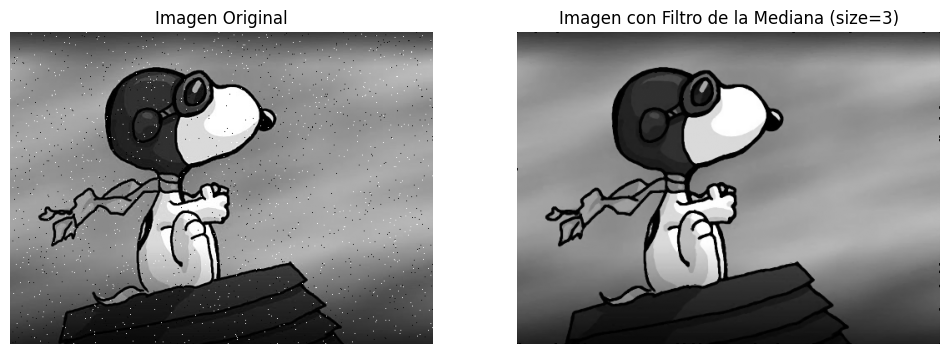

In [55]:

# Parámetros del filtro de la mediana
kernel_size_median = 3 # Debe ser impar, por ejemplo 3, 5, 7...

# Aplicar el filtro de la mediana a la imagen en escala de grises
ima_mediana = mediana_filtro(ima_grises, kernel_size_median)

# Visualizar la imagen original y la imagen filtrada
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(ima_grises, cmap='gray')
axs[0].set_title('Imagen Original')
axs[0].axis('off')

axs[1].imshow(ima_mediana, cmap='gray')
axs[1].set_title(f'Imagen con Filtro de la Mediana (size={kernel_size_median})')
axs[1].axis('off')

plt.show()

# Todos los métodos juntos

Text(0.5, 1.0, 'Imagen con Filtro de la Mediana (size=3)')

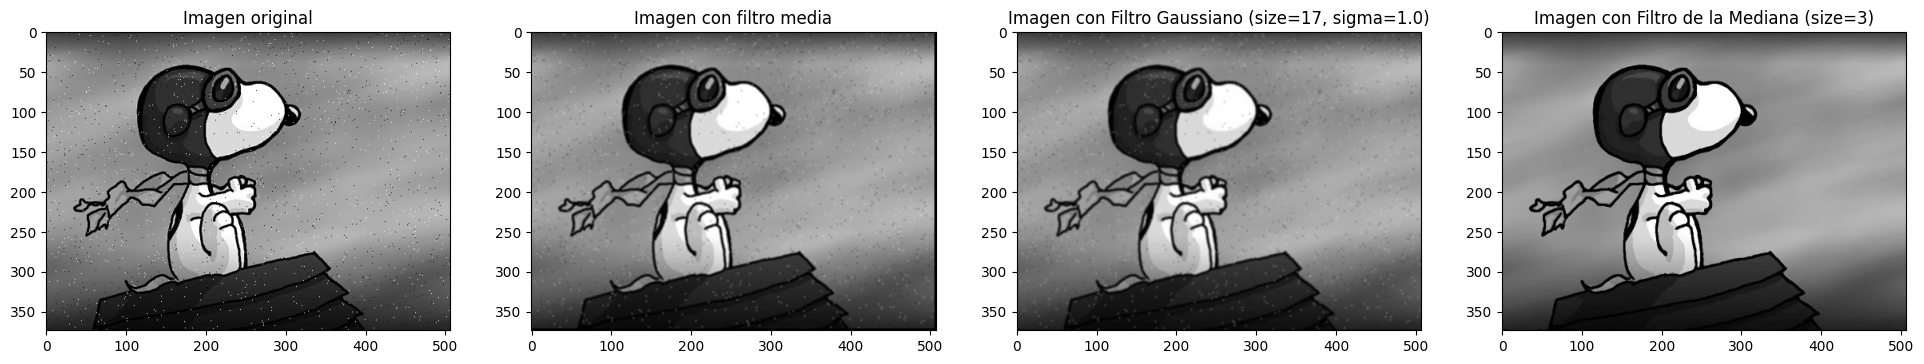

In [58]:
fig, axs = plt.subplots(1, 4, figsize=(24, 6))

axs[0].imshow(ima_grises, cmap = 'gray')
axs[0].set_title('Imagen original')
axs[1].imshow(ima_filtrada, cmap = 'gray')
axs[1].set_title('Imagen con filtro media')
axs[2].imshow(ima_gaussiana, cmap='gray')
axs[2].set_title(f'Imagen con Filtro Gaussiano (size={kernel_size}, sigma={sigma})')
axs[3].imshow(ima_mediana, cmap='gray')
axs[3].set_title(f'Imagen con Filtro de la Mediana (size={kernel_size_median})')
